In [ ]:
#@title Import all necessary libraries

# General python library
import os
import cv2
import numpy as np
from PIL import Image
from matplotlib import pyplot as plt
import matplotlib.animation as animation

# Torch library
import torch
from torch.utils.data import Dataset
from torch.utils.data import TensorDataset
from torch.utils.data import DataLoader
from torch.utils.data import random_split
from torch import nn
from torchvision import datasets
from torchvision.transforms import ToTensor

# Colab
from google.colab import drive

In [ ]:
#@title Useful functions

def load_image(filename):
  im_pil = Image.open(os.path.join(srcpath, filename))
  im = np.array(im_pil).astype(np.float32) / 255
  return im

def train(dataloader,
          model,
          loss_fn,
          optimizer,
          loss_print_iter: int=100
          ) -> None:
    size = len(dataloader.dataset)

    # Set the model to the training mod
    model.train()

    for batch, (image, label) in enumerate(dataloader):
        image, label = image.to(device), label.to(device)

        # Compute prediction error
        pred = model(image)
        loss = loss_fn(pred, label)

        # Backpropagation

        # Computes gradients of the loss with respect to all parameters
        # in the model that require gradients, storing them in the .grad
        # attribute of each parameter.
        loss.backward()

        # Updates all the model parameters using the gradients computed in the
        # previous step, moving parameters in the direction that reduces the
        # loss.
        optimizer.step()

        # Clear gradient for next iterations.
        optimizer.zero_grad()

        if batch % 100 == 0:
          loss, current = loss.item(), (batch + 1) * len(image)
          print(f"loss: {loss:>7f}  [{current:>5d}/{size:>5d}]")

def test(dataloader, model, loss_fn):
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    model.eval()
    test_loss, correct = 0, 0
    with torch.no_grad():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)
            pred = model(X)
            test_loss += loss_fn(pred, y).item()
            correct += (pred.argmax(1) == y).type(torch.float).sum().item()
    test_loss /= num_batches
    correct /= size
    print(f"Test Error: \n Accuracy: {(100*correct):>0.1f}%, Avg loss: {test_loss:>8f} \n")

**Note:** Update the `srcpath` below to the right path on your Google Drive.

In [ ]:
#@title At last, mount your colab

drive.mount('/content/drive')
srcpath = 'your_srcpath'  #@param {type:'string'}
srcpath = os.path.join('/content/drive/My Drive', srcpath)
print('srcpath = ', srcpath)

Mounted at /content/drive
srcpath =  /content/drive/My Drive/cuhk_courses/ierg4160_asset/assign3


This block may take about 10-20 seconds to download the dataset.

In [ ]:
#@title Load the MNIST dataset

training_data = datasets.MNIST(
    root="data",
    train=True,
    download=True,
    transform=ToTensor()
)

test_data = datasets.MNIST(
    root="data",
    train=False,
    download=True,
    transform=ToTensor()
)

# Create data loaders.
batch_size = 64    #@param {type:"integer"}
train_dataloader = DataLoader(training_data, batch_size=batch_size)
test_dataloader = DataLoader(test_data, batch_size=batch_size)

100%|██████████| 9.91M/9.91M [00:00<00:00, 44.6MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.16MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 10.1MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 10.6MB/s]


Let us check how the shape of input and output. The input is 28x28 single channel image. The output is a single class label, whose value is 0-9 (10 possible values).

Each time we load an image, we actually load a batch, and first dimension is the batch size.

In [ ]:
#@title Define **loss**

loss_fn = nn.CrossEntropyLoss()

In [ ]:
#@title Also setup a training device.

device = 'cpu'

In [ ]:
class NeuralNetwork1(nn.Module):
    def __init__(self):
        super().__init__()
        self.network = nn.Sequential(
            nn.Flatten(),             # This flatten image, which converts 28x28 image to 756 vector
            nn.Linear(28*28, 128),    # nn.Linear(a, b) means the input is a channels and the output is b chnnals
            nn.Linear(128, 128),      # Similarly, this is 128-channel input and 128-channel output.
            nn.Linear(128, 10)        # Since the output is 10-class, so the output must be 10 channels.
        )

    def forward(self, x):
        return self.network(x)

In [ ]:
model_1 = NeuralNetwork1().to(device)
learning_rate = 1e-1
optimizer = torch.optim.SGD(model_1.parameters(), lr=learning_rate)

In [ ]:
# For each epoch, we first run training to update the parameters, and run test to check the accuracy

epochs = 1
for t in range(epochs):
    print(f"Epoch {t+1}\n-------------------------------")
    train(train_dataloader, model_1, loss_fn, optimizer)
    test(test_dataloader, model_1, loss_fn)
print("Done!")

Epoch 1
-------------------------------
loss: 2.298683  [   64/60000]
loss: 0.465015  [ 6464/60000]
loss: 0.349844  [12864/60000]
loss: 0.392093  [19264/60000]
loss: 0.262401  [25664/60000]
loss: 0.354335  [32064/60000]
loss: 0.262804  [38464/60000]
loss: 0.375300  [44864/60000]
loss: 0.425488  [51264/60000]
loss: 0.469860  [57664/60000]
Test Error: 
 Accuracy: 90.7%, Avg loss: 0.324139 

Done!


The accuracy should be about 90%.

In [ ]:
#@title Define network

class NeuralNetwork3(nn.Module):
    def __init__(self):
        super().__init__()

        self.network = nn.Sequential(
            nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, padding=1),
                                                 # A convolutional network
                                                 # After this layer, the image is 28x28 with 32 channels
            nn.ReLU(),
            nn.MaxPool2d(2, 2),                  # nn.MaxPool2d(2, 2) is a 2x2 pooling layer
                                                 # After this layer, the image is 14x14 with 32 channels
            nn.Conv2d(in_channels=32, out_channels=32, kernel_size=3, padding=1),
                                                 # After this layer, the image is still 14x14 with 32 channels
            nn.ReLU(),
            nn.MaxPool2d(2, 2),                  # After this layer, the image is 2x2 with 32 channels
            nn.Flatten(),
            nn.Linear(7*7*32, 10)
        )

    def forward(self, x):
        return self.network(x)

# Individual Project Task 1
Train CNN for 10 Epochs and Plot Accuracy Curve

In [ ]:
#import library
import time
import matplotlib.pyplot as plt

In [ ]:
def test_and_return_acc(dataloader, model, loss_fn):
    size = len(dataloader.dataset)
    model.eval()
    correct = 0
    with torch.no_grad():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)
            pred = model(X)
            correct += (pred.argmax(1) == y).type(torch.float).sum().item()
    return 100 * (correct / size)

Epoch 1
-------------------------------
loss: 2.308721  [   64/60000]
loss: 0.249480  [ 6464/60000]
loss: 0.183941  [12864/60000]
loss: 0.301204  [19264/60000]
loss: 0.048941  [25664/60000]
loss: 0.154311  [32064/60000]
loss: 0.090137  [38464/60000]
loss: 0.147169  [44864/60000]
loss: 0.217161  [51264/60000]
loss: 0.231044  [57664/60000]
Test Error: 
 Accuracy: 96.9%, Avg loss: 0.099558 

Epoch 2
-------------------------------
loss: 0.111675  [   64/60000]
loss: 0.130187  [ 6464/60000]
loss: 0.057695  [12864/60000]
loss: 0.163457  [19264/60000]
loss: 0.027777  [25664/60000]
loss: 0.112717  [32064/60000]
loss: 0.095511  [38464/60000]
loss: 0.117047  [44864/60000]
loss: 0.199804  [51264/60000]
loss: 0.140822  [57664/60000]
Test Error: 
 Accuracy: 97.9%, Avg loss: 0.063020 

Epoch 3
-------------------------------
loss: 0.059381  [   64/60000]
loss: 0.145592  [ 6464/60000]
loss: 0.041168  [12864/60000]
loss: 0.096016  [19264/60000]
loss: 0.021996  [25664/60000]
loss: 0.085130  [32064/600

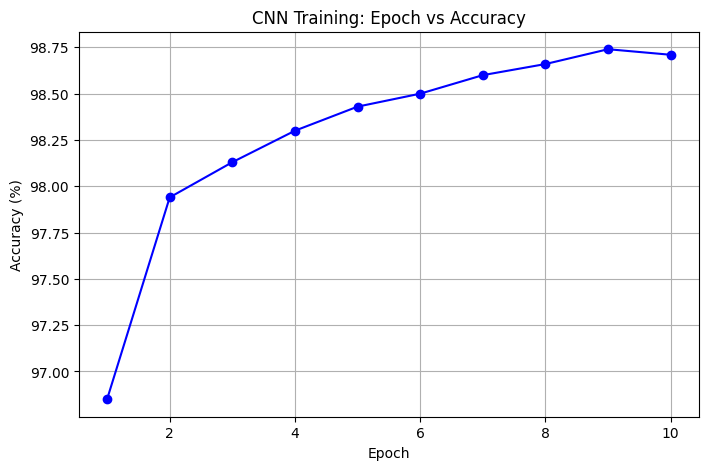

In [ ]:
#10 Epochs Training
model_cnn = NeuralNetwork3().to(device)
learning_rate = 1e-1
optimizer = torch.optim.SGD(model_cnn.parameters(), lr=learning_rate)
epochs = 10
history_acc = []

for t in range(epochs):
    print(f"Epoch {t+1}\n-------------------------------")
    train(train_dataloader, model_cnn, loss_fn, optimizer)
    test(test_dataloader, model_cnn, loss_fn)
    acc = test_and_return_acc(test_dataloader, model_cnn, loss_fn)
    history_acc.append(acc)
print("Done!")


plt.figure(figsize=(8, 5))
plt.plot(range(1, epochs + 1), history_acc, marker='o', color='b')
plt.title("CNN Training: Epoch vs Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.grid(True)
plt.show()

Batch size comparison

Batch Size 16
-------------------------------
loss: 2.303343  [   16/60000]
loss: 0.188110  [ 1616/60000]
loss: 0.112572  [ 3216/60000]
loss: 0.148825  [ 4816/60000]
loss: 0.099323  [ 6416/60000]
loss: 0.032001  [ 8016/60000]
loss: 0.083714  [ 9616/60000]
loss: 0.018746  [11216/60000]
loss: 0.429718  [12816/60000]
loss: 0.042234  [14416/60000]
loss: 0.175742  [16016/60000]
loss: 0.142421  [17616/60000]
loss: 0.057818  [19216/60000]
loss: 0.163314  [20816/60000]
loss: 0.022756  [22416/60000]
loss: 0.069908  [24016/60000]
loss: 0.174397  [25616/60000]
loss: 0.311542  [27216/60000]
loss: 0.012220  [28816/60000]
loss: 0.051629  [30416/60000]
loss: 0.145881  [32016/60000]
loss: 0.051737  [33616/60000]
loss: 0.061334  [35216/60000]
loss: 0.167304  [36816/60000]
loss: 0.004908  [38416/60000]
loss: 0.132281  [40016/60000]
loss: 0.083051  [41616/60000]
loss: 0.478122  [43216/60000]
loss: 0.252757  [44816/60000]
loss: 0.175313  [46416/60000]
loss: 0.006643  [48016/60000]
loss: 0.002620  [49616/6

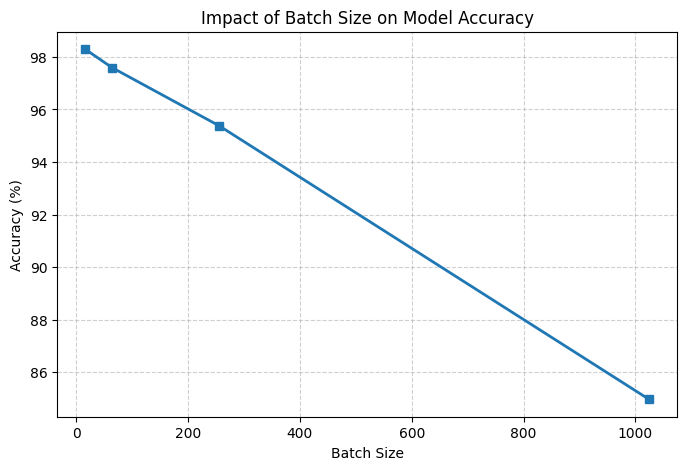

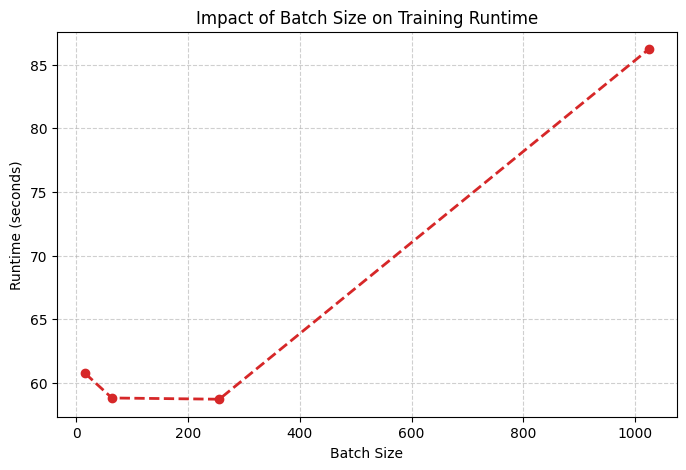

In [ ]:
batch_sizes = [16, 64, 256, 1024]
bs_accuracy = []
bs_runtime = []

for bs in batch_sizes:
    print(f"Batch Size {bs}\n-------------------------------")
    # Re-prepare data loaders
    tmp_train_loader = DataLoader(training_data, batch_size=bs, shuffle=True)
    tmp_test_loader = DataLoader(test_data, batch_size=bs)

    model_tmp = NeuralNetwork3().to(device)
    opt_tmp = torch.optim.SGD(model_tmp.parameters(), lr=1e-1)

    start_time = time.time()
    # Train for 1 epoch to measure runtime
    train(tmp_train_loader, model_tmp, loss_fn, opt_tmp)
    end_time = time.time()

    acc = test_and_return_acc(tmp_test_loader, model_tmp, loss_fn)

    bs_runtime.append(end_time - start_time)
    bs_accuracy.append(acc)
    print(f"Acc {acc:.2f}%, Time {end_time - start_time:.2f}s")

# Plotting Batch Size Results
# --- Plot 1: Batch Size vs Accuracy ---
plt.figure(figsize=(8, 5))
plt.plot(batch_sizes, bs_accuracy, color='tab:blue', marker='s', linewidth=2)
plt.title("Impact of Batch Size on Model Accuracy")
plt.xlabel("Batch Size")
plt.ylabel("Accuracy (%)")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# --- Plot 2: Batch Size vs Runtime ---
plt.figure(figsize=(8, 5))
plt.plot(batch_sizes, bs_runtime, color='tab:red', marker='o', linestyle='--', linewidth=2)
plt.title("Impact of Batch Size on Training Runtime")
plt.xlabel("Batch Size")
plt.ylabel("Runtime (seconds)")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

Learning Rate Exploration

LR: 0.001
-------------------------------
loss: 2.303567  [   64/60000]
loss: 2.300701  [ 6464/60000]
loss: 2.295470  [12864/60000]
loss: 2.278470  [19264/60000]
loss: 2.275601  [25664/60000]
loss: 2.268357  [32064/60000]
loss: 2.255194  [38464/60000]
loss: 2.259566  [44864/60000]
loss: 2.244869  [51264/60000]
loss: 2.213685  [57664/60000]
Test Error: 
 Accuracy: 53.8%, Avg loss: 2.215295 

loss: 2.220161  [   64/60000]
loss: 2.197151  [ 6464/60000]
loss: 2.184637  [12864/60000]
loss: 2.118334  [19264/60000]
loss: 2.115988  [25664/60000]
loss: 2.084905  [32064/60000]
loss: 1.983398  [38464/60000]
loss: 1.994913  [44864/60000]
loss: 1.906318  [51264/60000]
loss: 1.764288  [57664/60000]
Test Error: 
 Accuracy: 73.4%, Avg loss: 1.740258 

loss: 1.766965  [   64/60000]
loss: 1.598759  [ 6464/60000]
loss: 1.516435  [12864/60000]
loss: 1.323585  [19264/60000]
loss: 1.212965  [25664/60000]
loss: 1.124332  [32064/60000]
loss: 0.902919  [38464/60000]
loss: 1.030693  [44864/60000]
loss: 0.931884

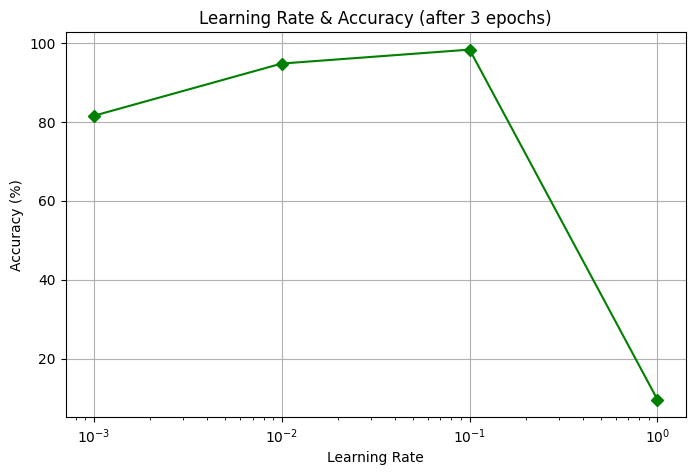

In [ ]:
learning_rates = [1e-3, 1e-2, 1e-1, 1.0]
lr_results = []

for lr in learning_rates:
    model_lr = NeuralNetwork3().to(device)
    optimizer = torch.optim.SGD(model_lr.parameters(), lr=lr)
    print(f"LR: {lr}\n-------------------------------")
    # Train for 3 epochs
    for t in range(3):
        train(train_dataloader, model_lr, loss_fn, optimizer)
        test(test_dataloader, model_lr, loss_fn)
    acc = test_and_return_acc(test_dataloader, model_lr, loss_fn)
    lr_results.append(acc)
    print(f"Accuracy {acc:.2f}%\n")

plt.figure(figsize=(8, 5))
plt.semilogx(learning_rates, lr_results, marker='D', color='green')
plt.title("Learning Rate & Accuracy (after 3 epochs)")
plt.xlabel("Learning Rate")
plt.ylabel("Accuracy (%)")
plt.grid(True)
plt.show()

Implement a new network by changing ReLu to Sigmoid

**The code is directly copy from NeuralNetwork3**


In [ ]:
class NeuralNetworkSigmoid(nn.Module):
    def __init__(self):
        super().__init__()

        self.network = nn.Sequential(
            nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, padding=1),
                                                 # A convolutional network
                                                 # After this layer, the image is 28x28 with 32 channels
            nn.Sigmoid(),
            nn.MaxPool2d(2, 2),                  # nn.MaxPool2d(2, 2) is a 2x2 pooling layer
                                                 # After this layer, the image is 14x14 with 32 channels
            nn.Conv2d(in_channels=32, out_channels=32, kernel_size=3, padding=1),
                                                 # After this layer, the image is still 14x14 with 32 channels
            nn.Sigmoid(),
            nn.MaxPool2d(2, 2),                  # After this layer, the image is 2x2 with 32 channels
            nn.Flatten(),
            nn.Linear(7*7*32, 10)
        )

    def forward(self, x):
        return self.network(x)

Test the training result and compare it with the neural network used in Task 1, for 10 epochs

Neurak Network (using Sigmoid)

Epoch 1
-------------------------------
loss: 2.348024  [   64/60000]
loss: 2.288398  [ 6464/60000]
loss: 2.301752  [12864/60000]
loss: 2.301676  [19264/60000]
loss: 2.271441  [25664/60000]
loss: 2.154393  [32064/60000]
loss: 1.543610  [38464/60000]
loss: 0.922567  [44864/60000]
loss: 0.911575  [51264/60000]
loss: 0.564261  [57664/60000]
Test Error: 
 Accuracy: 73.8%, Avg loss: 0.792802 

Epoch 2
-------------------------------
loss: 0.800901  [   64/60000]
loss: 0.644756  [ 6464/60000]
loss: 0.442383  [12864/60000]
loss: 0.742689  [19264/60000]
loss: 0.414766  [25664/60000]
loss: 0.620120  [32064/60000]
loss: 0.440120  [38464/60000]
loss: 0.358944  [44864/60000]
loss: 0.505346  [51264/60000]
loss: 0.476955  [57664/60000]
Test Error: 
 Accuracy: 84.5%, Avg loss: 0.471391 

Epoch 3
-------------------------------
loss: 0.438038  [   64/60000]
loss: 0.362493  [ 6464/60000]
loss: 0.317535  [12864/60000]
loss: 0.594670  [19264/60000]
loss: 0.243669  [25664/6

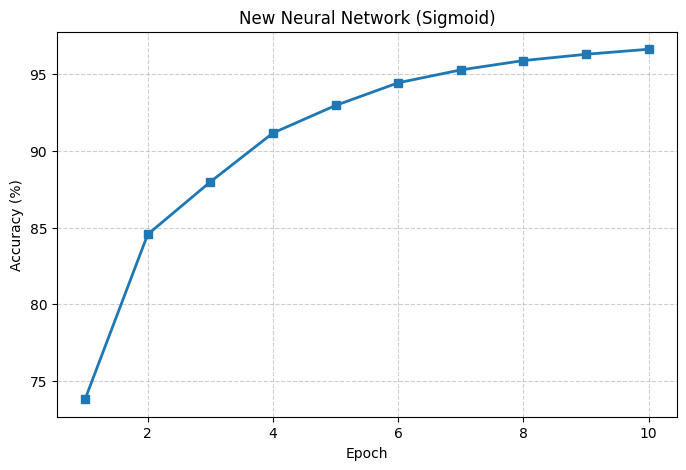

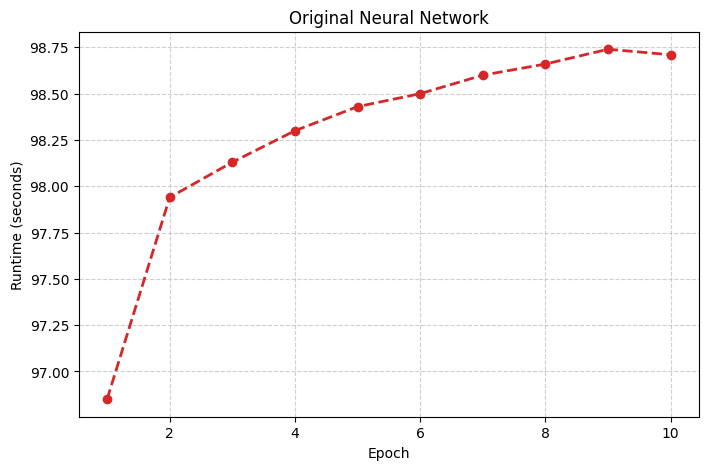

In [ ]:
model_sigmoid = NeuralNetworkSigmoid().to(device)
learning_rate = 1e-1
optimizer = torch.optim.SGD(model_sigmoid.parameters(), lr=learning_rate)
epochs = 10
history_accS = []
print(f"Neurak Network (using Sigmoid)\n")
for t in range(epochs):
    print(f"Epoch {t+1}\n-------------------------------")
    train(train_dataloader, model_sigmoid, loss_fn, optimizer)
    test(test_dataloader, model_sigmoid, loss_fn)
    acc = test_and_return_acc(test_dataloader, model_sigmoid, loss_fn)
    history_accS.append(acc)
print("Done!")

plt.figure(figsize=(8, 5))
plt.plot(range(1, epochs + 1), history_accS, color='tab:blue', marker='s', linewidth=2)
plt.title("New Neural Network (Sigmoid)")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


plt.figure(figsize=(8, 5))
plt.plot(range(1, epochs + 1), history_acc, color='tab:red', marker='o', linestyle='--', linewidth=2)
plt.title("Original Neural Network")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

#Individual Project Task 2
# Denoising image

*Create a dataset*

In [ ]:
training_data_denoising = datasets.MNIST(
    root="data",
    train=True,
    download=True,
    transform=ToTensor()
)

testing_data_denoising = datasets.MNIST(
    root="data",
    train=True,
    download=True,
    transform=ToTensor()
)

clean_train = training_data_denoising.data.numpy()
clean_train = clean_train.astype(np.float32) / 255.0

clean_test = testing_data_denoising.data.numpy()
clean_test = clean_test.astype(np.float32) / 255.0

Adding noise

In [ ]:
sigma = 0.3

# Create noisy training data
noisy_train = clean_train + sigma* np.random.normal(loc=0.0, scale=1.0, size= clean_train.shape)

# Create noisy test data
noisy_test = clean_test + sigma* np.random.normal(0, sigma, size= clean_test.shape)

# Cliping
#noisy_train = np.clip(noisy_train, 0., 1.)
#noisy_test = np.clip(noisy_test, 0., 1.)

In [ ]:
# Prepare Training Dataset
train_ds = TensorDataset(torch.from_numpy(noisy_train).unsqueeze(1),torch.from_numpy(clean_train).unsqueeze(1))
train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)

# Prepare Test Dataset
test_ds = TensorDataset(torch.from_numpy(noisy_test).unsqueeze(1),torch.from_numpy(clean_test).unsqueeze(1))
test_loader = DataLoader(test_ds, batch_size=64, shuffle=False)

Comparison between noisy and clean image

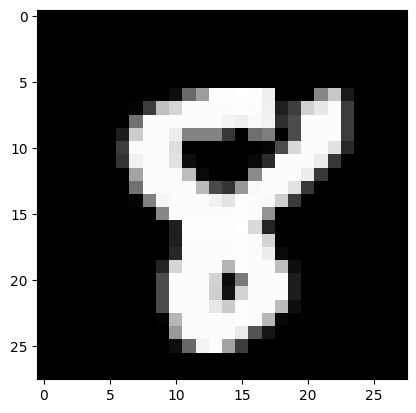

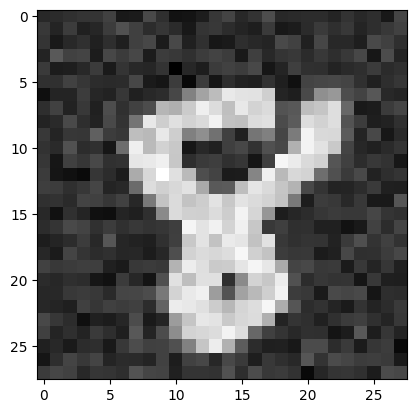

In [ ]:
# show original image
index = np.random.randint(len(clean_test))
plt.imshow(clean_test[index].reshape(28,28))
plt.show()
# show noisy image
plt.imshow(noisy_test[index].reshape(28,28))
plt.show()

Implement a simplified U-Net architecture

In [ ]:
class UNetDenoiser(nn.Module):
    def __init__(self):
        super(UNetDenoiser, self).__init__()

        # Encoder: Downsampling
        self.enc1 = nn.Conv2d(1, 16, kernel_size=3, padding=1)
        self.enc2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2) # Reduces 28x28 -> 14x14

        # Decoder: Upsampling
        self.upsample = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
        self.dec1 = nn.Conv2d(32 + 16, 16, kernel_size=3, padding=1) # +16 for skip connection
        self.dec2 = nn.Conv2d(16, 1, kernel_size=3, padding=1)

        self.relu = nn.ReLU() # Standard non-linear operator

    def forward(self, x):
        # Encoder
        x1 = self.relu(self.enc1(x))
        x2 = self.pool(x1)
        x2 = self.relu(self.enc2(x2))

        # Decoder with Skip Connection
        x_up = self.upsample(x2)
        # Concatenate original encoder features (x1) with upsampled features
        x_cat = torch.cat([x_up, x1], dim=1)

        x_out = self.relu(self.dec1(x_cat))
        x_out = torch.sigmoid(self.dec2(x_out)) # Final layer to keep output in [0, 1] range
        return x_out

**Setup MSE Loss**

In [ ]:
criterion = nn.MSELoss()

*Add the training process*

**By feeding the model with nousy images and calculating the loss based on the original image**

In [ ]:
import torch.optim as optim

# Initialization
model = UNetDenoiser().to(device)
optimizer = optim.Adam(model.parameters(), lr=0.001)

epochs = 10

for epoch in range(epochs):
    model.train()
    train_loss = 0
    for noisy_imgs, clean_imgs in train_loader:
        noisy_imgs, clean_imgs = noisy_imgs.to(device).float(), clean_imgs.to(device).float()

        # Forward pass
        outputs = model(noisy_imgs)
        loss = criterion(outputs, clean_imgs)

        # Backward pass and optimization
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    print(f"Epoch [{epoch+1}/{epochs}], Loss: {train_loss/len(train_loader):.4f}")

Epoch [1/10], Loss: 0.0107
Epoch [2/10], Loss: 0.0054
Epoch [3/10], Loss: 0.0050
Epoch [4/10], Loss: 0.0048
Epoch [5/10], Loss: 0.0047
Epoch [6/10], Loss: 0.0046
Epoch [7/10], Loss: 0.0045
Epoch [8/10], Loss: 0.0045
Epoch [9/10], Loss: 0.0044
Epoch [10/10], Loss: 0.0044


Running the denoise model on noisy input

In [ ]:
model.eval()
with torch.no_grad():
    # Get a batch of test images
    noisy_test, clean_test = next(iter(test_loader))
    noisy_test = noisy_test.to(device).float()

    # Get denoised output
    denoised_output = model(noisy_test).cpu()

See the result

Noisy input

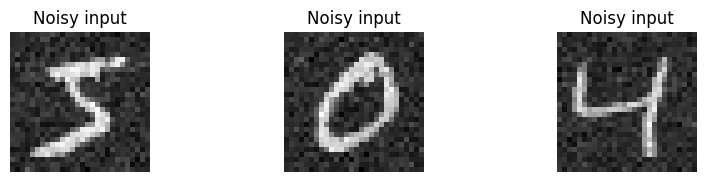

In [ ]:
plt.figure(figsize=(10, 4))
for i in range(3):
    # Plot Noisy Input
    plt.subplot(2, 3, i + 1)
    plt.imshow(noisy_test[i].cpu().squeeze(), cmap='gray')
    plt.title("Noisy input")
    plt.axis('off')

Denoise output

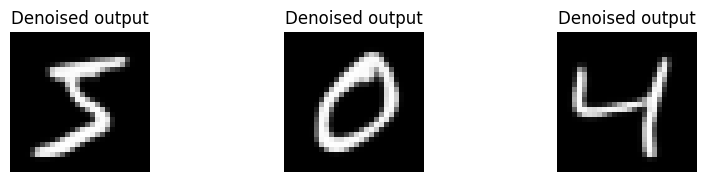

In [ ]:
plt.figure(figsize=(10, 4))
for i in range(3):
    # Plot Noisy Input
    plt.subplot(2, 3, i + 1)
    plt.imshow(denoised_output[i].cpu().squeeze(), cmap='gray')
    plt.title("Denoised output")
    plt.axis('off')